- Topic: **Parasite clearance** times **scheme**
- Creation date: 06/2025
- Author: Miguel Garrido Zornoza (mgarrizoraca@gmail.com)

References

- Bretscher *et al.* 2011 ; DOI: 10.1016/j.epidem.2011.03.002
- Sama *et al.* 2006a ; DOI: 10.1016/j.trstmh.2005.11.001

Nomenclature

- MT: Malaria Therapy dataset

Rationale

- About *P. falciparum* clearance times

In [92]:
from datetime import datetime
from IPython.display import display, Markdown

todays_date = str(datetime.now().date())

display(Markdown(f'#### Last update: {todays_date}'))

#### Last update: 2025-08-21

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [49]:
μ = [5.2,1.66]
σ1 = [0.73,1.20]
σ2 = [0.73,0.73]
labels = ["MT (PfPR ~ 0 %) [Sama et al. 2006a]", "Ghana (PfPR ~ 75%) [Bretscher et al. 2011]"]
colors = ["orange","royalblue"]
colors2 = ["red","blue"]

x = np.linspace(1,1000,4000)

In [37]:
def pdf_lognorm(x,μ,σ):
    return 1/(x*σ*np.sqrt(2*np.pi))*np.exp(-((np.log(x)-μ)**2/(2*σ**2)))
def pdf_norm(x,μ,σ):
    return 1/(np.sqrt(2*np.pi*σ**2))*np.exp(-(x-μ)**2/(2*σ**2))
def pdf_expon(x,μ):
    return μ*np.exp(-x*μ)

10.80
236.62


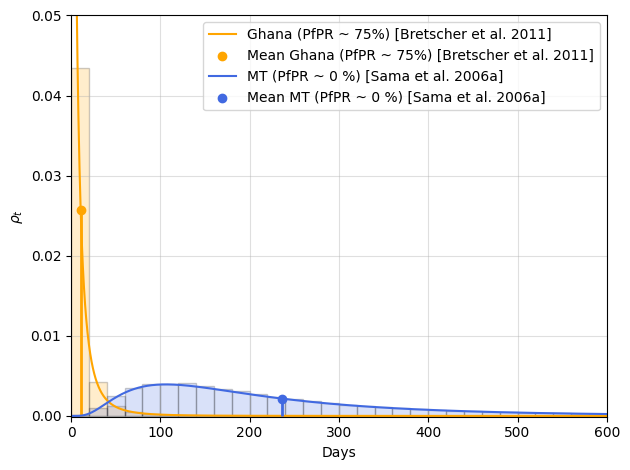

In [13]:
plt.subplots(dpi = 100)

for i in range(len(μ)):

    σ = σ1
    plt.plot(x,st.lognorm.pdf(x = x, scale = np.exp(μ[i]), s = σ[i]), color = colors[i], label = labels[i])

    data=np.random.lognormal(μ[i], σ[i] , int(1e5))
    plt.hist(data, bins=30, range =(0,600), density=True, alpha=0.2, color = colors[i], edgecolor = "k")

    mean = np.exp(μ[i]+σ[i]**2/2)
    print(f"{mean:.2f}")
    plt.scatter(mean,st.lognorm.pdf(x = mean, scale = np.exp(μ[i]), s = σ[i]), color = colors[i], label = f'Mean {labels[i]}')
    plt.vlines(mean,0,st.lognorm.pdf(x = mean, scale = np.exp(μ[i]), s = σ[i]),color = colors[i],lw=2)

    if False:
        σ = σ2
        plt.plot(x,st.lognorm.pdf(x = x, scale = np.exp(μ[i]), s = σ[i]), color = colors2[i], label = labels[i])
    
        data=np.random.lognormal(μ[i], σ[i] , int(1e5))
        plt.hist(data, bins=30, range =(0,600), density=True, alpha=0.2, color = colors2[i], edgecolor = "k")
    
        mean = np.exp(μ[i]+σ[i]**2/2)
        print(f"{mean:.2f}")
        plt.scatter(mean,st.lognorm.pdf(x = mean, scale = np.exp(μ[i]), s = σ[i]), color = colors2[i])
        plt.vlines(mean,0,st.lognorm.pdf(x = mean, scale = np.exp(μ[i]), s = σ[i]),color = colors2[i],lw=2)

plt.ylabel(r"$\rho_t$")
plt.xlabel("Days")
plt.legend()
plt.xlim(0,600)
#plt.xscale("log")

plt.ylim(-0.0001,0.05)
#plt.yscale("log")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('infc_times.pdf', transparent=True, dpi =150)

$$ \Delta \mu \equiv \frac{\mu(e_l = 1)-\mu(e_l = 0)}{1} $$

$$ \mu(e_l) = \Delta \mu \cdot e_l + \mu(0)$$

$$ \sigma(e_l) = \Delta \sigma \cdot e_l + \sigma(0) $$

In [33]:
x = np.linspace(0,1)
mu = (μ[1]-μ[0])*x + μ[0]
sig= (σ1[1]-σ1[0])*x + σ1[0]

In [35]:
μ[1] - μ[0]

-3.54

In [36]:
σ1[1]-σ1[0]

0.47

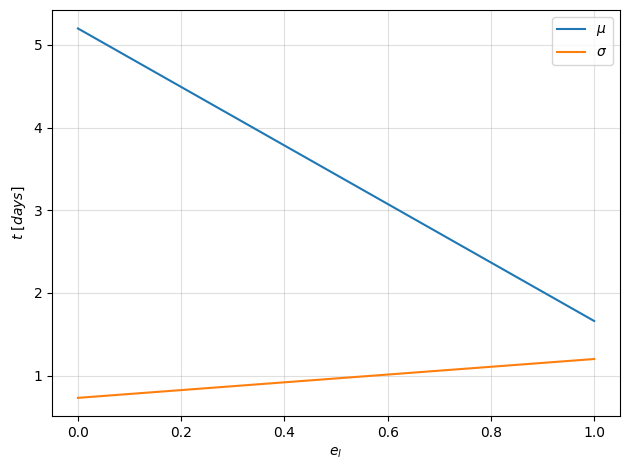

In [32]:
plt.subplots(dpi=100)

plt.plot(x,mu,label=r'$\mu$')
plt.plot(x,sig,label=r'$\sigma$')

plt.legend()
plt.xlabel(r'$e_l$')
plt.ylabel(r'$t \ [days]$')
plt.grid(alpha=0.4)
plt.tight_layout()

In [56]:
Δμ = μ[1] - μ[0]
Δσ = σ1[1] - σ1[0]

def μ_e(e,Δμ,μ1):
    return Δμ*e + μ1
def σ_e(e,Δσ,σ1):
    return Δσ*e + σ1

In [57]:
Δσ

0.47

In [58]:
μ_e(0,Δμ,μ[0])

5.2

In [59]:
σ_e(0,Δσ,σ[0])

1.2

In [88]:
labels = [r"$e_l = 0$ (MT, PfPR ~ 0 % [Sama et al. 2006a])", r"$e_l=0.5$ (Parametrization)", r"$e_l = 1$ (Ghana, PfPR ~ 75%, [Bretscher et al. 2011)]"]
colors = ["purple","royalblue","orange"]

In [89]:
e = np.linspace(0,1,3)

5.20, 0.73,236.62
3.43, 0.96,49.19
1.66, 1.20,10.80


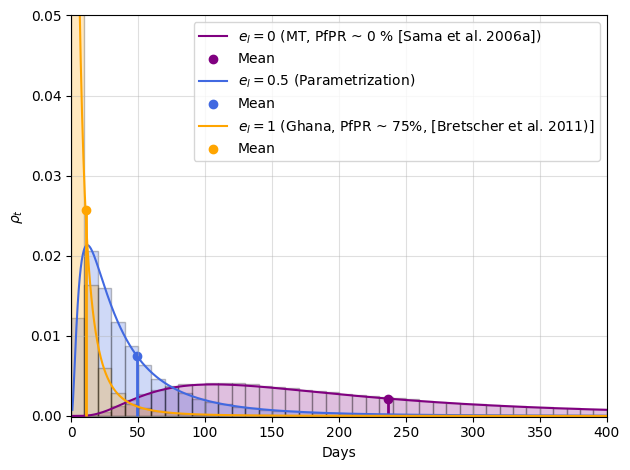

In [93]:
plt.subplots(dpi = 100)
x = np.linspace(1,1000,4000)
for indx,i in enumerate(e):

    
    μ_i = μ_e(i,Δμ,μ[0])
    σ_i = σ_e(i,Δσ,σ1[0])
    
    plt.plot(x,st.lognorm.pdf(x = x, scale = np.exp(μ_i), s = σ_i), color = colors[indx], label = labels[indx])

    data=np.random.lognormal(μ_i, σ_i , int(1e5))
    plt.hist(data, bins=60, range =(0,600), density=True, alpha=0.25, color = colors[indx], edgecolor = "k")

    mean = np.exp(μ_i+σ_i**2/2)
    print(f"{μ_i:.2f}, {σ_i:.2f},{mean:.2f}")
    
    plt.scatter(mean,st.lognorm.pdf(x = mean, scale = np.exp(μ_i), s = σ_i), color = colors[indx], label = f'Mean')
    plt.vlines(mean,0,st.lognorm.pdf(x = mean, scale = np.exp(μ_i), s = σ_i),color = colors[indx],lw=2)

plt.ylabel(r"$\rho_t$")
plt.xlabel("Days")
plt.legend()
plt.xlim(0,400)
#plt.xscale("log")

plt.ylim(-0.0001,0.05)
#plt.yscale("log")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('infc_times_param.pdf', transparent=True, dpi =150)